In [1]:
%pip install plotly 

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from plotly import express as px
from plotly import graph_objects as go
from plotly.subplots import make_subplots
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv("../Data/processed/processed.csv")

In [4]:
df.head()

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi,pulse_pressure,hypertension,overweight
0,2,168,62.0,110,80,1,1,0,0,1,0,50.4,22.0,30,0,0
1,1,156,85.0,140,90,3,1,0,0,1,1,55.4,34.9,50,1,1
2,1,165,64.0,130,70,3,1,0,0,0,1,51.6,23.5,60,0,0
3,2,169,82.0,150,100,1,1,0,0,1,1,48.2,28.7,50,1,1
4,1,156,56.0,100,60,1,1,0,0,0,0,47.8,23.0,40,0,0


In [5]:
df.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
gender,68640.0,1.348616,0.476536,1.0,1.0,1.0,2.0,2.0
height,68640.0,164.395790,7.983654,100.0,159.0,165.0,170.0,250.0
weight,68640.0,74.119433,14.306778,30.0,65.0,72.0,82.0,200.0
ap_hi,68640.0,126.676005,16.695471,60.0,120.0,120.0,140.0,240.0
ap_lo,68640.0,81.307882,9.454697,40.0,80.0,80.0,90.0,182.0
cholesterol,68640.0,1.364744,0.678945,1.0,1.0,1.0,2.0,3.0
gluc,68640.0,1.225801,0.571665,1.0,1.0,1.0,1.0,3.0
smoke,68640.0,0.087952,0.283227,0.0,0.0,0.0,0.0,1.0
alco,68640.0,0.053351,0.224734,0.0,0.0,0.0,0.0,1.0
active,68640.0,0.803365,0.397457,0.0,1.0,1.0,1.0,1.0


## Clasificación binaria

Balance de cardio (0 vs 1)

In [6]:
# Conteo y porcentaje
conteo = df['cardio'].astype(int).value_counts().sort_index()
pct    = df['cardio'].astype(int).value_counts(normalize=True).sort_index() * 100

resumen = pd.DataFrame({
    'pacientes':     conteo.values,
    'porcentaje (%)': pct.round(1).values
}, index=['Sin enfermedad (0)', 'Con enfermedad (1)'])

print("=== Balance de la variable objetivo ===\n")
print(resumen.to_string())
print(f"\nRatio mayoría/minoría: {conteo.max() / conteo.min():.2f}")

=== Balance de la variable objetivo ===

                    pacientes  porcentaje (%)
Sin enfermedad (0)      34681            50.5
Con enfermedad (1)      33959            49.5

Ratio mayoría/minoría: 1.02


In [7]:
import os
os.makedirs('../img', exist_ok=True)
print("✓ Carpeta img/ creada")

✓ Carpeta img/ creada


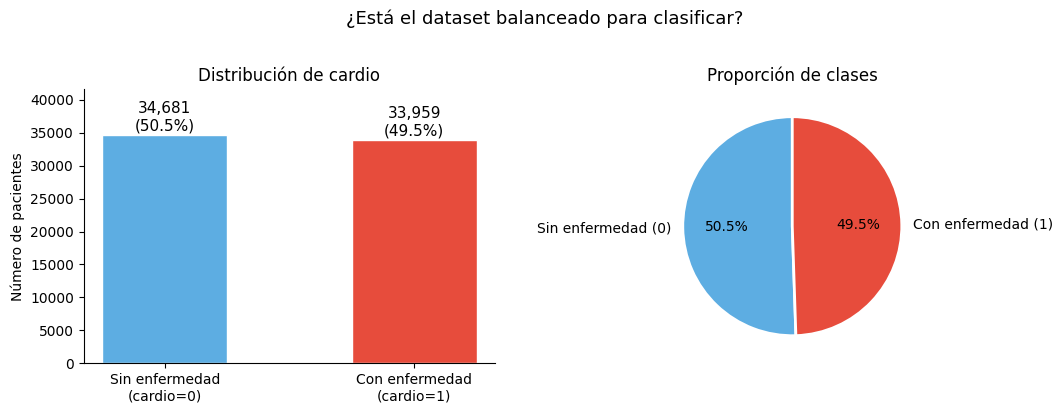

In [8]:

media_global = df['cardio'].astype(int).mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Barras
ax = axes[0]
bars = ax.bar(['Sin enfermedad\n(cardio=0)', 'Con enfermedad\n(cardio=1)'],
              conteo.values,
              color=['#5DADE2', '#E74C3C'], edgecolor='white', width=0.5)

for bar, val, p in zip(bars, conteo.values, pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{val:,}\n({p:.1f}%)', ha='center', va='bottom', fontsize=11)

ax.set_title('Distribución de cardio', fontsize=12)
ax.set_ylabel('Número de pacientes')
ax.set_ylim(0, conteo.max() * 1.2)
sns.despine()

# Pie chart
ax2 = axes[1]
ax2.pie(conteo.values,
        labels=['Sin enfermedad (0)', 'Con enfermedad (1)'],
        colors=['#5DADE2', '#E74C3C'],
        autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax2.set_title('Proporción de clases', fontsize=12)

plt.suptitle('¿Está el dataset balanceado para clasificar?', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../img/s1a_balance_target.png', bbox_inches='tight')
plt.show()

## Confirmar que no hay fugas de información

In [9]:
# Una fuga de información ocurre cuando el modelo tiene acceso durante el entrenamiento
# a datos que en la vida real no estarían disponibles en el momento de predecir.
# Ejemplo clásico: incluir el resultado de un examen que solo se hace DESPUÉS
# de diagnosticar la enfermedad.

print("=== Revisión de posibles fugas de información ===\n")

columnas_info = {
    'age_years':      ('✓ disponible', 'Se conoce antes del diagnóstico'),
    'gender':         ('✓ disponible', 'Se conoce antes del diagnóstico'),
    'height':         ('✓ disponible', 'Se mide en consulta básica'),
    'weight':         ('✓ disponible', 'Se mide en consulta básica'),
    'ap_hi':          ('✓ disponible', 'Se mide en consulta básica'),
    'ap_lo':          ('✓ disponible', 'Se mide en consulta básica'),
    'cholesterol':    ('✓ disponible', 'Resultado de análisis de sangre rutinario'),
    'gluc':           ('✓ disponible', 'Resultado de análisis de sangre rutinario'),
    'smoke':          ('✓ disponible', 'Declarado por el paciente'),
    'alco':           ('✓ disponible', 'Declarado por el paciente'),
    'active':         ('✓ disponible', 'Declarado por el paciente'),
    'bmi':            ('✓ calculada',  'Derivada de height y weight — sin fuga'),
    'pulse_pressure': ('✓ calculada',  'Derivada de ap_hi y ap_lo — sin fuga'),
    'cardio':         ('⚠ TARGET',     'Variable a predecir — nunca entra como feature'),
}

print(f"  {'Columna':<20} {'Estado':<16} {'Motivo'}")
print("  " + "-" * 65)
for col, (estado, motivo) in columnas_info.items():
    print(f"  {col:<20} {estado:<16} {motivo}")

=== Revisión de posibles fugas de información ===

  Columna              Estado           Motivo
  -----------------------------------------------------------------
  age_years            ✓ disponible     Se conoce antes del diagnóstico
  gender               ✓ disponible     Se conoce antes del diagnóstico
  height               ✓ disponible     Se mide en consulta básica
  weight               ✓ disponible     Se mide en consulta básica
  ap_hi                ✓ disponible     Se mide en consulta básica
  ap_lo                ✓ disponible     Se mide en consulta básica
  cholesterol          ✓ disponible     Resultado de análisis de sangre rutinario
  gluc                 ✓ disponible     Resultado de análisis de sangre rutinario
  smoke                ✓ disponible     Declarado por el paciente
  alco                 ✓ disponible     Declarado por el paciente
  active               ✓ disponible     Declarado por el paciente
  bmi                  ✓ calculada      Derivada de height y

In [10]:
# Si alguna variable tiene correlación > 0.9 con cardio es señal de fuga
print("=== Correlación de cada variable con cardio ===\n")
print("Alerta: correlación > 0.9 podría indicar fuga de información\n")

cols_check = ['age_years', 'height', 'weight', 'ap_hi', 'ap_lo',
              'bmi', 'pulse_pressure']

corr_target = (df[cols_check + ['cardio']]
               .apply(lambda x: x.astype(float))
               .corr()['cardio']
               .drop('cardio')
               .sort_values(ascending=False))

for col, val in corr_target.items():
    bar   = '█' * int(abs(val) * 30)
    signo = '+' if val >= 0 else '-'
    flag  = '⚠ REVISAR' if abs(val) > 0.9 else ''
    print(f"  {col:<22} {signo}{abs(val):.3f}  {bar}  {flag}")

print(f"\n{'✓ Sin fugas detectadas' if corr_target.abs().max() < 0.9 else '⚠ Revisar variables marcadas'}")

=== Correlación de cada variable con cardio ===

Alerta: correlación > 0.9 podría indicar fuga de información

  ap_hi                  +0.428  ████████████  
  ap_lo                  +0.340  ██████████  
  pulse_pressure         +0.337  ██████████  
  age_years              +0.239  ███████  
  bmi                    +0.186  █████  
  weight                 +0.180  █████  
  height                 -0.012    

✓ Sin fugas detectadas


In [11]:
ratio        = conteo.max() / conteo.min()
max_corr     = corr_target.abs().max()
n_filas      = len(df)
n_features   = len(df.columns) - 1  # sin cardio

print("=" * 52)
print("  CONCLUSIÓN — ¿LISTO PARA CLASIFICACIÓN BINARIA?")
print("=" * 52)

checks = {
    f'Volumen suficiente ({n_filas:,} filas)':           n_filas > 10000,
    f'Dataset balanceado (ratio {ratio:.2f})':           ratio < 1.5,
    f'Sin fugas de información (corr max {max_corr:.2f})': max_corr < 0.9,
    f'Features disponibles ({n_features} columnas)':     n_features >= 5,
    'Variable objetivo binaria (0/1)':                   True,
}

for condicion, ok in checks.items():
    icono = '✓' if ok else '✗'
    print(f"  {icono}  {condicion}")

todos_ok = all(checks.values())
print(f"""
  {'─' * 48}
  Veredicto: {'✓ El dataset está listo para entrenar un clasificador.' 
               if todos_ok else 
               '✗ Revisar los puntos marcados antes de modelar.'}

  Próximo paso recomendado:
  → Usar train_test_split con stratify=y
  → Modelos sugeridos para empezar:
      · Regresión logística  (interpretable, buen baseline)
      · Random Forest        (robusto, maneja bien este tipo de datos)
      · XGBoost              (alto rendimiento en datos tabulares)
  {'─' * 48}
""")

  CONCLUSIÓN — ¿LISTO PARA CLASIFICACIÓN BINARIA?
  ✓  Volumen suficiente (68,640 filas)
  ✓  Dataset balanceado (ratio 1.02)
  ✓  Sin fugas de información (corr max 0.43)
  ✓  Features disponibles (15 columnas)
  ✓  Variable objetivo binaria (0/1)

  ────────────────────────────────────────────────
  Veredicto: ✓ El dataset está listo para entrenar un clasificador.

  Próximo paso recomendado:
  → Usar train_test_split con stratify=y
  → Modelos sugeridos para empezar:
      · Regresión logística  (interpretable, buen baseline)
      · Random Forest        (robusto, maneja bien este tipo de datos)
      · XGBoost              (alto rendimiento en datos tabulares)
  ────────────────────────────────────────────────



## Salud pública y campañas preventivas

Violinplots de numéricas vs cardio

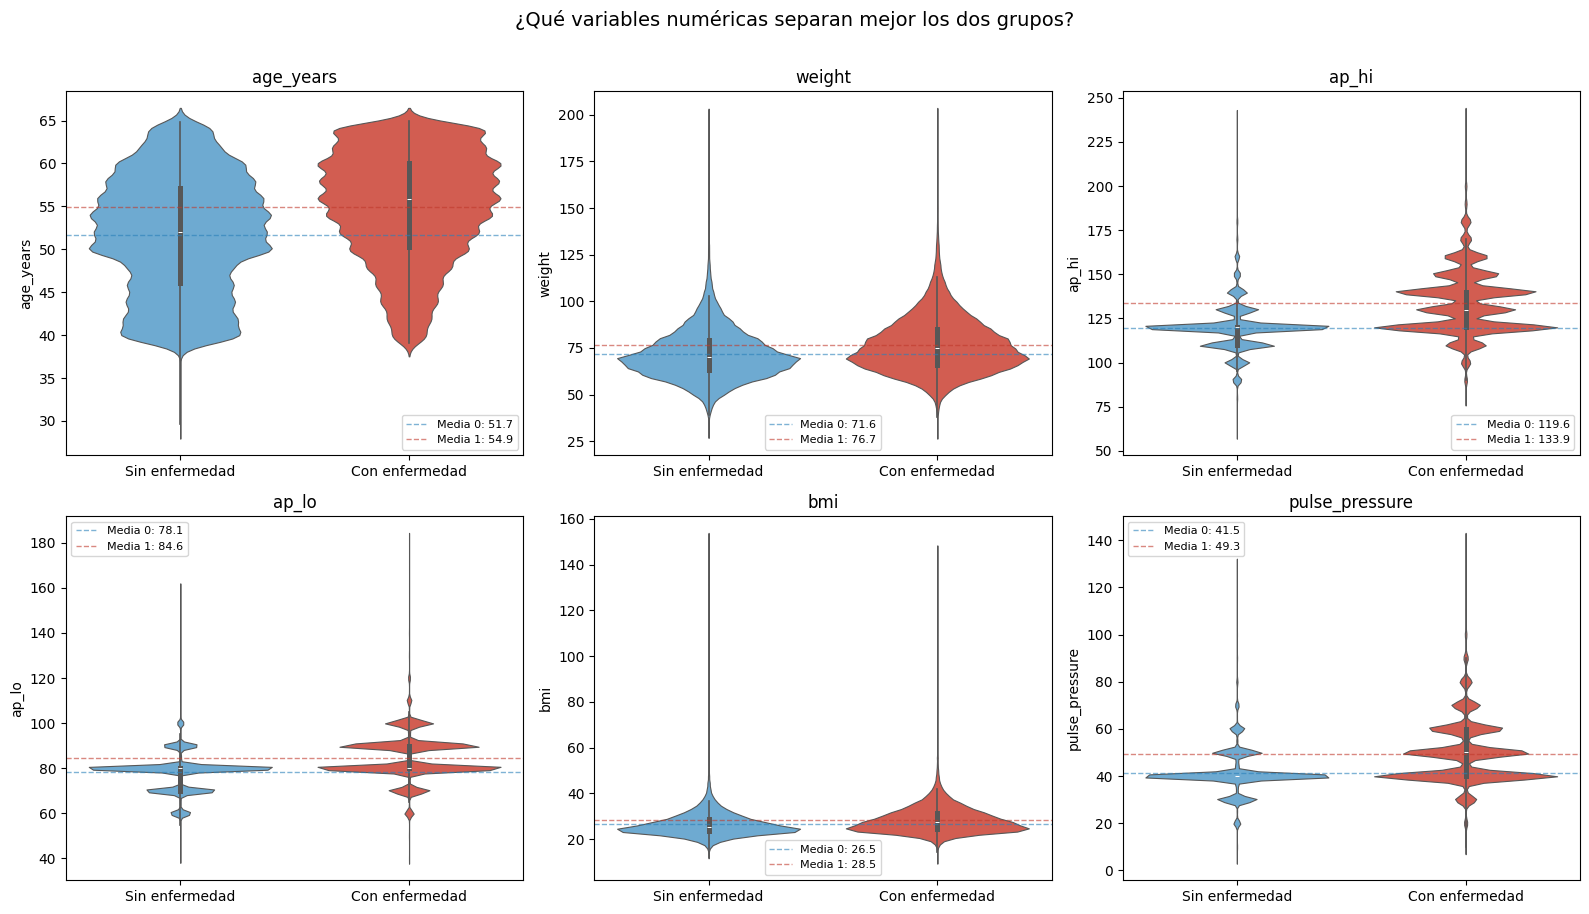

In [12]:
cols_violin = ['age_years', 'weight', 'ap_hi', 'ap_lo', 'bmi', 'pulse_pressure']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, col in zip(axes.flatten(), cols_violin):
    sns.violinplot(data=df, x='cardio', y=col, ax=ax,
                   hue='cardio',                          # ← fix FutureWarning
                   palette={0: '#5DADE2', 1: '#E74C3C'},
                   inner='box', linewidth=0.8,
                   legend=False)                          # ← oculta leyenda automática

    m0 = df[df['cardio'] == 0][col].mean()
    m1 = df[df['cardio'] == 1][col].mean()
    ax.axhline(m0, color='#2980B9', linewidth=1, linestyle='--', alpha=0.6, label=f'Media 0: {m0:.1f}')
    ax.axhline(m1, color='#C0392B', linewidth=1, linestyle='--', alpha=0.6, label=f'Media 1: {m1:.1f}')

    ax.set_xticks([0, 1])                                 # ← fix UserWarning
    ax.set_xticklabels(['Sin enfermedad', 'Con enfermedad'])
    ax.set_title(col, fontsize=12)
    ax.set_xlabel('')
    ax.legend(fontsize=8)

plt.suptitle('¿Qué variables numéricas separan mejor los dos grupos?', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../img/s2a_violinplots.png', bbox_inches='tight')
plt.show()

# Análisis de Violinplots: 6 Variables Numéricas

## Tipo de Gráfico
Los gráficos utilizados son **violinplots** (gráficos de violín), que combinan características de:
- **Distribución de densidad**: muestra la forma de la distribución de cada variable
- **Boxplot interno**: indica mediana, cuartiles y valores atípicos
- **Puntos individuales**: representan observaciones reales

## Resultados Principales

| Variable | Hallazgo |
|----------|----------|
| **age_years** | Distribuciones similares entre grupos, con una ligera tendencia hacia edades mayores en el grupo con enfermedad |
| **weight** | El grupo con enfermedad (1) tiende a tener mayor peso, con media más elevada |
| **ap_hi** | Diferencia clara: presión sistólica significativamente mayor en pacientes con enfermedad |
| **ap_lo** | Diferencia moderada: presión diastólica también más elevada en el grupo con enfermedad |
| **bmi** | Separación notable: índice de masa corporal claramente más alto en pacientes enfermos |
| **pulse_pressure** | Buena separación entre grupos: presión de pulso superior en el grupo con enfermedad |

## Conclusión
Las variables **ap_hi**, **ap_lo**, **bmi** y **pulse_pressure** son excelentes **predictores de la enfermedad cardiovascular**, mostrando claras diferencias entre los dos grupos. Las líneas punteadas indican las medias de cada grupo, facilitando la comparación visual.

## Barras de tasa de enfermedad por categórica

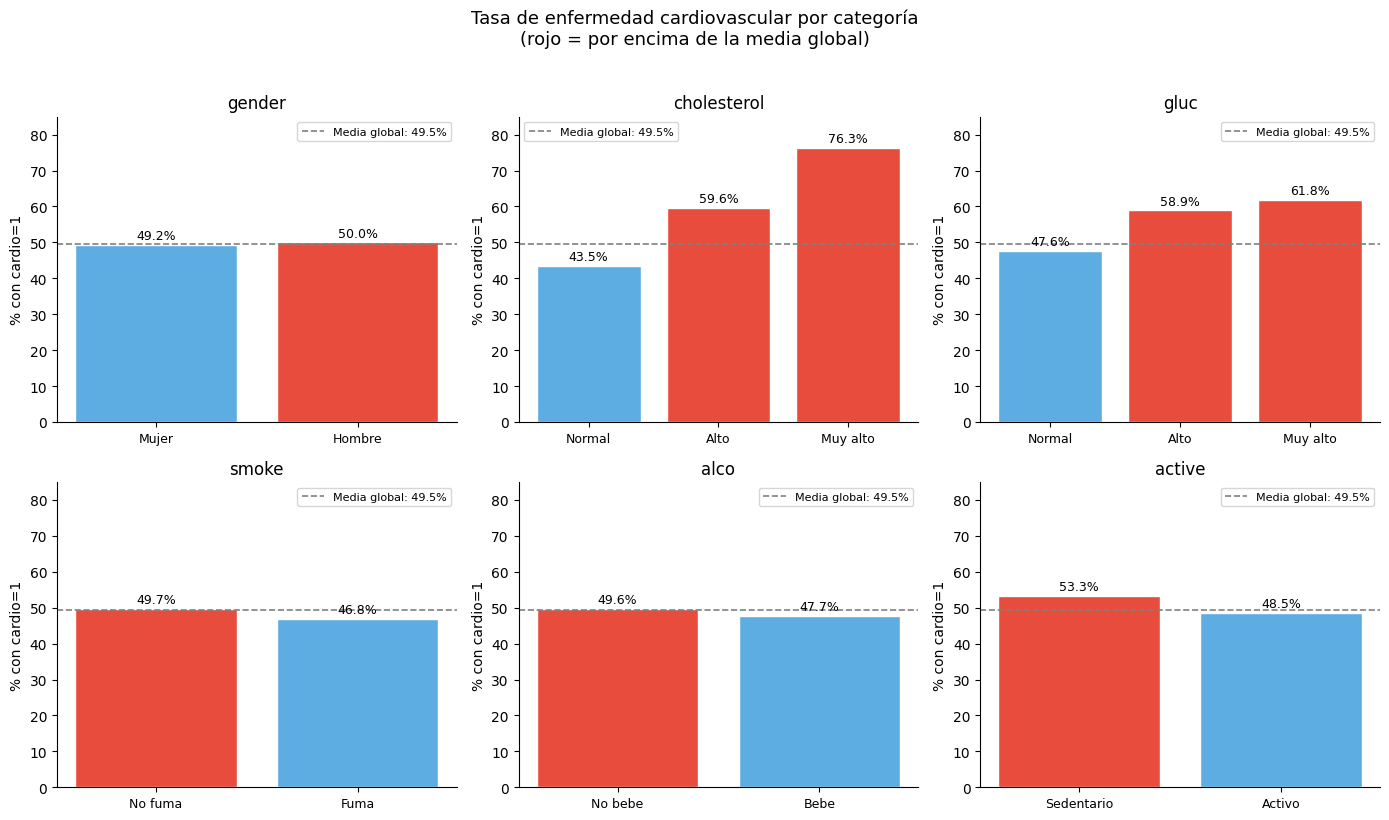

In [13]:
cols_cat = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
etiquetas = {
    'gender':      {1: 'Mujer', 2: 'Hombre'},
    'cholesterol': {1: 'Normal', 2: 'Alto', 3: 'Muy alto'},
    'gluc':        {1: 'Normal', 2: 'Alto', 3: 'Muy alto'},
    'smoke':       {0: 'No fuma', 1: 'Fuma'},
    'alco':        {0: 'No bebe', 1: 'Bebe'},
    'active':      {0: 'Sedentario', 1: 'Activo'},
}

media_global = df['cardio'].mean() * 100
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, col in zip(axes.flatten(), cols_cat):
    tasa = df.groupby(col)['cardio'].mean() * 100
    etiq = [etiquetas[col].get(k, str(k)) for k in tasa.index]

    colores = ['#E74C3C' if v > media_global else '#5DADE2' for v in tasa.values]
    bars = ax.bar(etiq, tasa.values, color=colores, edgecolor='white')

    ax.axhline(media_global, color='gray', linewidth=1.2, linestyle='--',
               label=f'Media global: {media_global:.1f}%')

    for bar, val in zip(bars, tasa.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

    ax.set_title(col, fontsize=12)
    ax.set_ylabel('% con cardio=1')
    ax.set_ylim(0, 85)
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', labelsize=9)
    sns.despine()

plt.suptitle('Tasa de enfermedad cardiovascular por categoría\n(rojo = por encima de la media global)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../img/s2b_categoricas_vs_cardio.png', bbox_inches='tight')
plt.show()

- Distribución objetivo: prácticamente balanceada (Sin enfermedad 50.5% vs Con enfermedad 49.5%), conteos similares (~34.7k vs 34.0k), por lo que el dataset no presenta fuerte desbalance de la variable target.
- Barras por categoría: la línea horizontal muestra la media global (49.5%). Las barras en rojo indican tasas por encima de esa media.
- Ejemplo concreto: en "active" los sedentarios presentan mayor tasa de enfermedad (53.3%) frente a los activos (48.6%).
- Interpretación práctica: enfocarse en las categorías coloreadas en rojo (mayor riesgo relativo) para priorizar intervenciones o variables en modelos predictivos; combinar esto con las variables numéricas (ap_hi, ap_lo, bmi, pulse_pressure) que muestran buena separación entre grupos.

## Ranking visual de poder predictivo

In [14]:
print("=" * 55)
print("  RANKING DE VARIABLES POR PODER PREDICTIVO")
print("=" * 55)

resultados = []

# Numéricas: diferencia porcentual de medias entre grupos
print("\nNuméricas — diferencia de media entre grupos:\n")
for col in cols_violin:
    m0   = df[df['cardio'] == 0][col].mean()
    m1   = df[df['cardio'] == 1][col].mean()
    diff = abs(m1 - m0) / m0 * 100
    resultados.append({'variable': col, 'tipo': 'numérica', 'diferencia': diff})
    bar  = '█' * int(diff / 2)
    print(f"  {col:<22} {diff:>6.1f}%  {bar}")

# Categóricas: diferencia entre tasa mínima y máxima
print("\nCategóricas — rango de tasa de cardio=1:\n")
for col in cols_cat:
    tasa = df.groupby(col)['cardio'].mean() * 100
    diff = tasa.max() - tasa.min()
    resultados.append({'variable': col, 'tipo': 'categórica', 'diferencia': diff})
    bar  = '█' * int(diff / 2)
    print(f"  {col:<22} {diff:>6.1f}pp  {bar}")

# Tabla ordenada
print("\n" + "=" * 55)
print("  RANKING GLOBAL (mayor diferencia = más predictiva)")
print("=" * 55)
ranking = pd.DataFrame(resultados).sort_values('diferencia', ascending=False)
ranking['posición'] = range(1, len(ranking) + 1)
print(ranking[['posición', 'variable', 'tipo', 'diferencia']].to_string(index=False))

  RANKING DE VARIABLES POR PODER PREDICTIVO

Numéricas — diferencia de media entre grupos:

  age_years                 6.3%  ███
  weight                    7.2%  ███
  ap_hi                    11.9%  █████
  ap_lo                     8.2%  ████
  bmi                       7.5%  ███
  pulse_pressure           19.0%  █████████

Categóricas — rango de tasa de cardio=1:

  gender                    0.8pp  
  cholesterol              32.7pp  ████████████████
  gluc                     14.2pp  ███████
  smoke                     2.9pp  █
  alco                      1.9pp  
  active                    4.7pp  ██

  RANKING GLOBAL (mayor diferencia = más predictiva)
 posición       variable       tipo  diferencia
        1    cholesterol categórica   32.714199
        2 pulse_pressure   numérica   18.952858
        3           gluc categórica   14.191597
        4          ap_hi   numérica   11.949933
        5          ap_lo   numérica    8.231933
        6            bmi   numérica    7.527

## Conclusión: top 3 variables más relevantes

In [15]:
top3 = ranking.head(3)

print("=" * 55)
print("  CONCLUSIÓN — TOP 3 VARIABLES MÁS RELEVANTES")
print("  para campañas de salud pública")
print("=" * 55)

for _, row in top3.iterrows():
    col  = row['variable']
    diff = row['diferencia']
    tipo = row['tipo']

    if tipo == 'numérica':
        m0 = df[df['cardio'] == 0][col].mean()
        m1 = df[df['cardio'] == 1][col].mean()
        detalle = f"media sin enfermedad: {m0:.1f} → con enfermedad: {m1:.1f}"
    else:
        tasa = df.groupby(col)['cardio'].mean() * 100
        cat_min = etiquetas[col].get(tasa.idxmin(), str(tasa.idxmin()))
        cat_max = etiquetas[col].get(tasa.idxmax(), str(tasa.idxmax()))
        detalle = f"tasa más baja en '{cat_min}', más alta en '{cat_max}'"

    print(f"\n  #{int(row['posición'])} {col.upper()} ({tipo})")
    print(f"     Diferencia entre grupos: {diff:.1f}")
    print(f"     {detalle}")

print("""
─────────────────────────────────────────────────────
  Implicación para salud pública:
  Intervenir sobre las variables del top 3 tiene el
  mayor impacto potencial en reducir el riesgo
  cardiovascular en la población.
─────────────────────────────────────────────────────""")

  CONCLUSIÓN — TOP 3 VARIABLES MÁS RELEVANTES
  para campañas de salud pública

  #1 CHOLESTEROL (categórica)
     Diferencia entre grupos: 32.7
     tasa más baja en 'Normal', más alta en 'Muy alto'

  #2 PULSE_PRESSURE (numérica)
     Diferencia entre grupos: 19.0
     media sin enfermedad: 41.5 → con enfermedad: 49.3

  #3 GLUC (categórica)
     Diferencia entre grupos: 14.2
     tasa más baja en 'Normal', más alta en 'Muy alto'

─────────────────────────────────────────────────────
  Implicación para salud pública:
  Intervenir sobre las variables del top 3 tiene el
  mayor impacto potencial en reducir el riesgo
  cardiovascular en la población.
─────────────────────────────────────────────────────


## ¿Existen perfiles de riesgo combinados?

segmentación para aseguradoras

Crear perfil de riesgo: hipertenso + sedentario + colesterol alto
Cruzar dos variables a la vez contra cardio (heatmap de tasas)
Comparar tasa de enfermedad entre perfiles

In [16]:
# Definir cada factor de riesgo como variable binaria
df['es_hipertenso']      = ((df['ap_hi'] >= 140) | (df['ap_lo'] >= 90)).astype(int)
df['es_sedentario']      = (df['active'] == 0).astype(int)
df['colesterol_alto']    = (df['cholesterol'] >= 2).astype(int)
df['sobrepeso']          = (df['bmi'] >= 25).astype(int)
df['glucosa_alta']       = (df['gluc'] >= 2).astype(int)

# Contar cuántos factores de riesgo acumula cada paciente
factores = ['es_hipertenso', 'es_sedentario', 'colesterol_alto', 'sobrepeso', 'glucosa_alta']
df['n_factores_riesgo'] = df[factores].sum(axis=1)

print("=== Distribución de factores de riesgo acumulados ===\n")
conteo_factores = df['n_factores_riesgo'].value_counts().sort_index()
for n, c in conteo_factores.items():
    tasa = df[df['n_factores_riesgo'] == n]['cardio'].astype(int).mean() * 100
    bar  = '█' * int(tasa / 2)
    print(f"  {n} factores → {c:>6,} pacientes  |  tasa cardio=1: {tasa:.1f}%  {bar}")

=== Distribución de factores de riesgo acumulados ===

  0 factores → 13,114 pacientes  |  tasa cardio=1: 25.2%  ████████████
  1 factores → 22,598 pacientes  |  tasa cardio=1: 37.7%  ██████████████████
  2 factores → 18,578 pacientes  |  tasa cardio=1: 61.9%  ██████████████████████████████
  3 factores → 10,037 pacientes  |  tasa cardio=1: 72.5%  ████████████████████████████████████
  4 factores →  3,786 pacientes  |  tasa cardio=1: 77.5%  ██████████████████████████████████████
  5 factores →    527 pacientes  |  tasa cardio=1: 81.6%  ████████████████████████████████████████


In [17]:
# Crear etiqueta de perfil legible
def asignar_perfil(row):
    partes = []
    if row['es_hipertenso']:   partes.append('Hipertenso')
    if row['es_sedentario']:   partes.append('Sedentario')
    if row['colesterol_alto']: partes.append('Col.Alto')
    return ' + '.join(partes) if partes else 'Sin factores'

df['perfil'] = df.apply(asignar_perfil, axis=1)

# Calcular tasa de cardio=1 por perfil
perfiles = (df.groupby('perfil')
              .agg(pacientes=('cardio', 'count'),
                   tasa_cardio=('cardio', lambda x: x.astype(int).mean() * 100))
              .reset_index()
              .sort_values('tasa_cardio', ascending=False))

print("=== Tasa de enfermedad por perfil de riesgo ===\n")
print(perfiles.to_string(index=False))

=== Tasa de enfermedad por perfil de riesgo ===

                            perfil  pacientes  tasa_cardio
Hipertenso + Sedentario + Col.Alto       1621    81.863048
             Hipertenso + Col.Alto       7084    81.648786
           Hipertenso + Sedentario       2962    77.548953
                        Hipertenso      11870    75.425442
             Sedentario + Col.Alto       1702    55.934195
                          Col.Alto       6761    51.516048
                        Sedentario       7212    36.245147
                      Sin factores      29428    29.050564


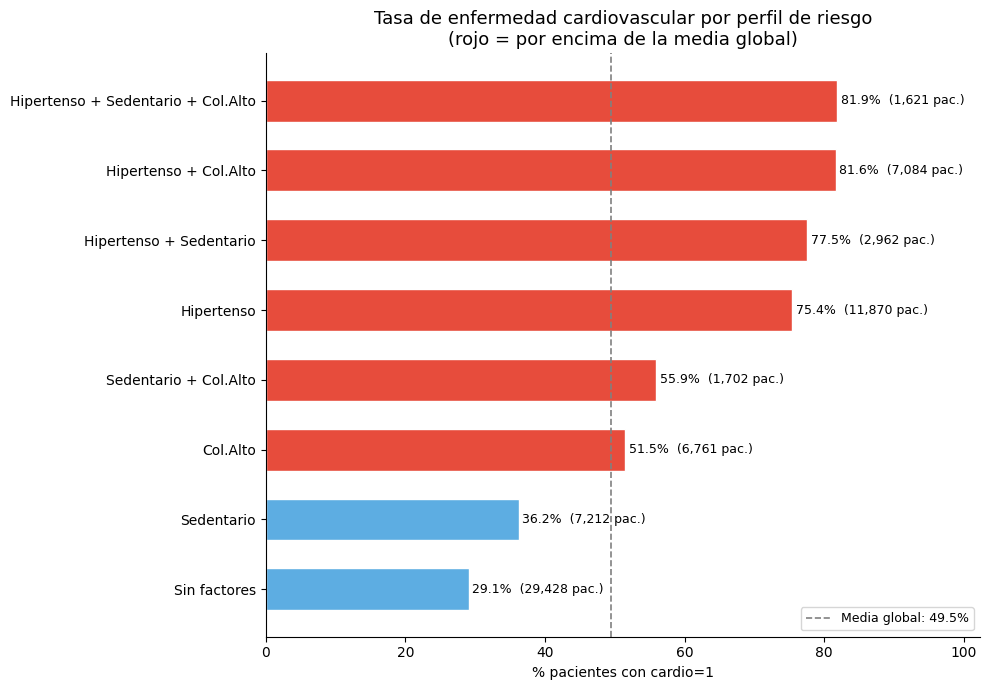

In [18]:
# Top 10 perfiles más frecuentes con al menos 100 pacientes
top_perfiles = (perfiles[perfiles['pacientes'] >= 100]
                .head(10)
                .sort_values('tasa_cardio', ascending=True))

media_global = df['cardio'].astype(int).mean() * 100

fig, ax = plt.subplots(figsize=(10, 7))

colores = ['#E74C3C' if t > media_global else '#5DADE2'
           for t in top_perfiles['tasa_cardio']]

bars = ax.barh(top_perfiles['perfil'], top_perfiles['tasa_cardio'],
               color=colores, edgecolor='white', height=0.6)

ax.axvline(media_global, color='gray', linewidth=1.2, linestyle='--',
           label=f'Media global: {media_global:.1f}%')

for bar, (_, row) in zip(bars, top_perfiles.iterrows()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{row['tasa_cardio']:.1f}%  ({row['pacientes']:,} pac.)",
            va='center', fontsize=9)

ax.set_xlabel('% pacientes con cardio=1')
ax.set_title('Tasa de enfermedad cardiovascular por perfil de riesgo\n(rojo = por encima de la media global)',
             fontsize=13)
ax.set_xlim(0, top_perfiles['tasa_cardio'].max() * 1.25)
ax.legend(fontsize=9)
sns.despine()
plt.tight_layout()
plt.savefig('../img/s3a_perfiles_riesgo.png', bbox_inches='tight')
plt.show()

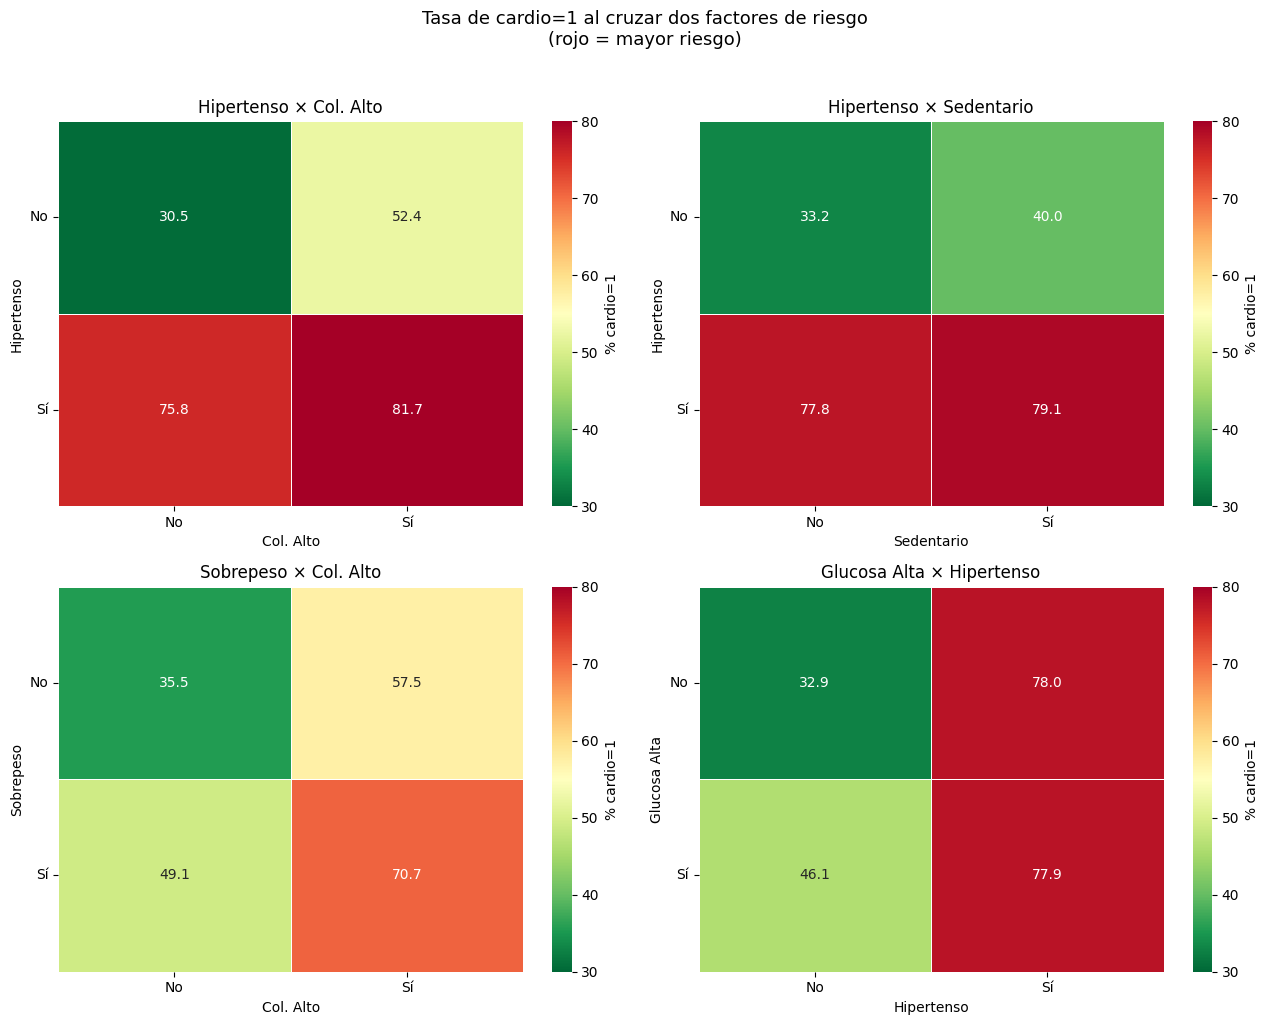

In [19]:
# Pares de variables más interesantes para cruzar
pares = [
    ('es_hipertenso', 'colesterol_alto'),
    ('es_hipertenso', 'es_sedentario'),
    ('sobrepeso',     'colesterol_alto'),
    ('glucosa_alta',  'es_hipertenso'),
]

etiq_factor = {
    'es_hipertenso':   'Hipertenso',
    'es_sedentario':   'Sedentario',
    'colesterol_alto': 'Col. Alto',
    'sobrepeso':       'Sobrepeso',
    'glucosa_alta':    'Glucosa Alta',
}

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for ax, (var_x, var_y) in zip(axes.flatten(), pares):
    pivot = (df.groupby([var_x, var_y])['cardio']
               .apply(lambda x: x.astype(int).mean() * 100)
               .unstack())

    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn_r',
                vmin=30, vmax=80, linewidths=0.5,
                cbar_kws={'label': '% cardio=1'}, ax=ax)

    ax.set_title(f'{etiq_factor[var_x]} × {etiq_factor[var_y]}', fontsize=12)
    ax.set_xlabel(etiq_factor[var_y])
    ax.set_ylabel(etiq_factor[var_x])
    ax.set_xticklabels(['No', 'Sí'])
    ax.set_yticklabels(['No', 'Sí'], rotation=0)

plt.suptitle('Tasa de cardio=1 al cruzar dos factores de riesgo\n(rojo = mayor riesgo)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../img/s3b_heatmap_pares.png', bbox_inches='tight')
plt.show()

In [20]:
# Perfil de mayor riesgo
peor_perfil = perfiles.iloc[0]

# Perfil de menor riesgo
mejor_perfil = perfiles[perfiles['pacientes'] >= 100].iloc[-1]

print("=" * 58)
print("  CONCLUSIÓN — SEGMENTACIÓN DE PERFILES DE RIESGO")
print("  Uso: aseguradoras y sistemas de salud")
print("=" * 58)

print(f"""
  Perfil de MAYOR riesgo detectado:
  → {peor_perfil['perfil']}
    Tasa de cardio=1: {peor_perfil['tasa_cardio']:.1f}%
    Pacientes en este grupo: {peor_perfil['pacientes']:,}

  Perfil de MENOR riesgo detectado:
  → {mejor_perfil['perfil']}
    Tasa de cardio=1: {mejor_perfil['tasa_cardio']:.1f}%
    Pacientes en este grupo: {mejor_perfil['pacientes']:,}

  Diferencia entre perfiles extremos:
  → {peor_perfil['tasa_cardio'] - mejor_perfil['tasa_cardio']:.1f} puntos porcentuales

  Implicación para aseguradoras:
  Los pacientes con {int(df['n_factores_riesgo'].max())} factores acumulados tienen
  una probabilidad {peor_perfil['tasa_cardio']/mejor_perfil['tasa_cardio']:.1f}x mayor de
  tener enfermedad cardiovascular que los de menor riesgo.
  Estos grupos deberían recibir intervención prioritaria.
""")

print("=" * 58)

# Tabla resumen por número de factores
print("\nResumen por número de factores acumulados:\n")
resumen_factores = (df.groupby('n_factores_riesgo')
                      .agg(pacientes=('cardio', 'count'),
                           tasa_cardio=('cardio', lambda x: x.astype(int).mean() * 100))
                      .reset_index())
resumen_factores.columns = ['factores de riesgo', 'pacientes', 'tasa cardio=1 (%)']
resumen_factores['tasa cardio=1 (%)'] = resumen_factores['tasa cardio=1 (%)'].round(1)
print(resumen_factores.to_string(index=False))

  CONCLUSIÓN — SEGMENTACIÓN DE PERFILES DE RIESGO
  Uso: aseguradoras y sistemas de salud

  Perfil de MAYOR riesgo detectado:
  → Hipertenso + Sedentario + Col.Alto
    Tasa de cardio=1: 81.9%
    Pacientes en este grupo: 1,621

  Perfil de MENOR riesgo detectado:
  → Sin factores
    Tasa de cardio=1: 29.1%
    Pacientes en este grupo: 29,428

  Diferencia entre perfiles extremos:
  → 52.8 puntos porcentuales

  Implicación para aseguradoras:
  Los pacientes con 5 factores acumulados tienen
  una probabilidad 2.8x mayor de
  tener enfermedad cardiovascular que los de menor riesgo.
  Estos grupos deberían recibir intervención prioritaria.


Resumen por número de factores acumulados:

 factores de riesgo  pacientes  tasa cardio=1 (%)
                  0      13114               25.2
                  1      22598               37.7
                  2      18578               61.9
                  3      10037               72.5
                  4       3786               77.5
      

## Correlaciones

Heatmap general. Detectar variables redundantes antes de modelar.

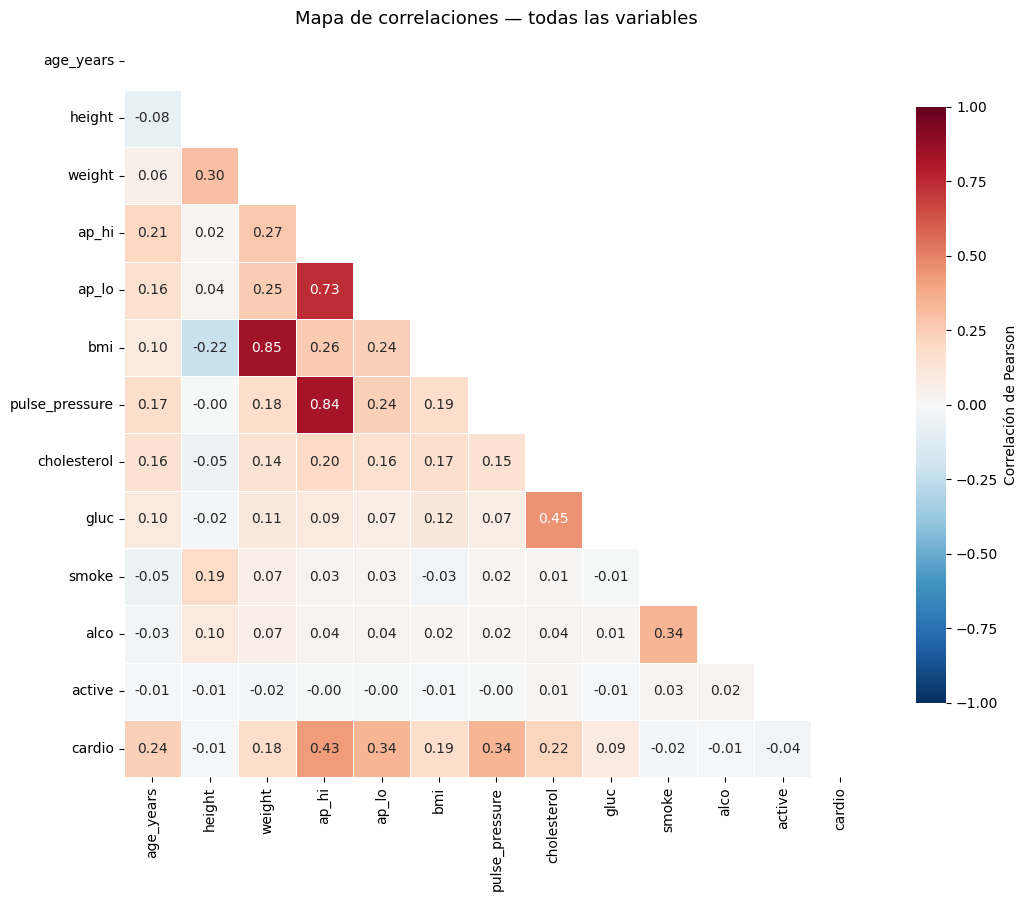

In [21]:
cols_corr = ['age_years', 'height', 'weight', 'ap_hi', 'ap_lo',
             'bmi', 'pulse_pressure', 'cholesterol', 'gluc',
             'smoke', 'alco', 'active', 'cardio']

# Convertir todo a float para poder calcular correlación
corr = df[cols_corr].astype(float).corr()

fig, ax = plt.subplots(figsize=(11, 9))

# Máscara para mostrar solo el triángulo inferior
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': 'Correlación de Pearson'},
            ax=ax)

ax.set_title('Mapa de correlaciones — todas las variables', fontsize=13)
plt.tight_layout()
plt.savefig('../img/s4a_heatmap_correlaciones.png', bbox_inches='tight')
plt.show()

In [22]:
corr_target = (df[cols_corr].astype(float)
               .corr()['cardio']
               .drop('cardio')
               .sort_values(ascending=False))

print("=== Correlación con la variable objetivo (cardio) ===\n")
print("Positiva → sube cardio cuando sube la variable")
print("Negativa → baja cardio cuando sube la variable\n")

for col, val in corr_target.items():
    barra  = '█' * int(abs(val) * 40)
    signo  = '+' if val >= 0 else '-'
    print(f"  {col:<22} {signo}{abs(val):.3f}  {barra}")

=== Correlación con la variable objetivo (cardio) ===

Positiva → sube cardio cuando sube la variable
Negativa → baja cardio cuando sube la variable

  ap_hi                  +0.428  █████████████████
  ap_lo                  +0.340  █████████████
  pulse_pressure         +0.337  █████████████
  age_years              +0.239  █████████
  cholesterol            +0.221  ████████
  bmi                    +0.186  ███████
  weight                 +0.180  ███████
  gluc                   +0.090  ███
  alco                   -0.009  
  height                 -0.012  
  smoke                  -0.016  
  active                 -0.038  █


In [23]:
print("=== Pares con correlación > 0.7 (posible redundancia) ===\n")

redundantes = []
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        val  = corr.iloc[i, j]
        c1   = corr.columns[i]
        c2   = corr.columns[j]
        if abs(val) > 0.7 and c1 != 'cardio' and c2 != 'cardio':
            redundantes.append({'var_1': c1, 'var_2': c2, 'correlación': round(val, 3)})

if redundantes:
    df_red = pd.DataFrame(redundantes).sort_values('correlación',
                          key=abs, ascending=False)
    print(df_red.to_string(index=False))
    print("\n⚠ En el modelado conviene conservar solo una de cada par.")
else:
    print("✓ No se detectaron pares con correlación > 0.7")

=== Pares con correlación > 0.7 (posible redundancia) ===

 var_1          var_2  correlación
weight            bmi        0.851
 ap_hi pulse_pressure        0.835
 ap_hi          ap_lo        0.735

⚠ En el modelado conviene conservar solo una de cada par.


In [24]:
# Variables con correlación más alta con cardio
top_positivas = corr_target[corr_target > 0].head(3)
top_negativas = corr_target[corr_target < 0].tail(2)

print("=" * 54)
print("  CONCLUSIÓN — CORRELACIONES")
print("=" * 54)

print("\n  Variables MÁS asociadas con cardio=1 (riesgo):")
for col, val in top_positivas.items():
    print(f"    + {col:<22} r = {val:.3f}")

print("\n  Variables MÁS asociadas con cardio=0 (protección):")
for col, val in top_negativas.items():
    print(f"    - {col:<22} r = {val:.3f}")

if redundantes:
    print("\n  Variables redundantes detectadas:")
    for r in redundantes:
        print(f"    · {r['var_1']} ↔ {r['var_2']}  (r = {r['correlación']})")
        print(f"      → conservar una sola en el modelo")

print(f"""
  {'─' * 50}
  Nota: correlación de Pearson mide relaciones lineales.
  Variables con r bajo pueden igualmente ser útiles
  en modelos no lineales como Random Forest o XGBoost.
  {'─' * 50}
""")

  CONCLUSIÓN — CORRELACIONES

  Variables MÁS asociadas con cardio=1 (riesgo):
    + ap_hi                  r = 0.428
    + ap_lo                  r = 0.340
    + pulse_pressure         r = 0.337

  Variables MÁS asociadas con cardio=0 (protección):
    - smoke                  r = -0.016
    - active                 r = -0.038

  Variables redundantes detectadas:
    · weight ↔ bmi  (r = 0.851)
      → conservar una sola en el modelo
    · ap_hi ↔ ap_lo  (r = 0.735)
      → conservar una sola en el modelo
    · ap_hi ↔ pulse_pressure  (r = 0.835)
      → conservar una sola en el modelo

  ──────────────────────────────────────────────────
  Nota: correlación de Pearson mide relaciones lineales.
  Variables con r bajo pueden igualmente ser útiles
  en modelos no lineales como Random Forest o XGBoost.
  ──────────────────────────────────────────────────



## Conclusiones

Una tabla resumen con los hallazgos de cada sección, directamente conectada a los tres usos del proyecto.

In [25]:
# ── Datos que necesitamos de secciones anteriores ──────────────────

# Sección 1 — balance
ratio_clases = conteo.max() / conteo.min()

# Sección 2 — top 3 variables por poder predictivo
# (viene del ranking de la celda 2c)
top3_vars = ranking.head(3)['variable'].tolist()

# Sección 3 — perfil de mayor y menor riesgo
perfil_alto  = perfiles.iloc[0]
perfil_bajo  = perfiles[perfiles['pacientes'] >= 100].iloc[-1]
diferencia_perfiles = perfil_alto['tasa_cardio'] - perfil_bajo['tasa_cardio']

# Sección 4 — variables redundantes y correlación máxima con cardio
var_mas_correlada = corr_target.idxmax()
corr_max          = corr_target.max()
n_redundantes     = len(redundantes)

In [26]:
print("=" * 65)
print("  RESUMEN DEL EDA — DATASET CARDIOVASCULAR")
print(f"  {len(df):,} pacientes · {len(df.columns)} variables")
print("=" * 65)

secciones = [
    {
        'seccion':  '1. Clasificación binaria',
        'hallazgo': f"Dataset balanceado (ratio {ratio_clases:.2f}) — listo para modelar",
        'accion':   "Usar stratify=y en train_test_split"
    },
    {
        'seccion':  '2. Factores de mayor peso',
        'hallazgo': f"Top 3 variables: {', '.join(top3_vars)}",
        'accion':   "Priorizar estas variables en campañas preventivas"
    },
    {
        'seccion':  '3. Perfiles de riesgo',
        'hallazgo': f"Diferencia entre perfil alto y bajo: {diferencia_perfiles:.1f} pp",
        'accion':   "Segmentar población para intervención prioritaria"
    },
    {
        'seccion':  '4. Correlaciones',
        'hallazgo': f"Variable más correlada con cardio: {var_mas_correlada} (r={corr_max:.2f}). "
                    f"{n_redundantes} par(es) redundante(s) detectado(s)",
        'accion':   "Eliminar variable redundante antes de modelar"
    },
]

for s in secciones:
    print(f"\n  ┌─ {s['seccion']}")
    print(f"  │  Hallazgo : {s['hallazgo']}")
    print(f"  └─ Acción   : {s['accion']}")

print()

  RESUMEN DEL EDA — DATASET CARDIOVASCULAR
  68,640 pacientes · 23 variables

  ┌─ 1. Clasificación binaria
  │  Hallazgo : Dataset balanceado (ratio 1.02) — listo para modelar
  └─ Acción   : Usar stratify=y en train_test_split

  ┌─ 2. Factores de mayor peso
  │  Hallazgo : Top 3 variables: cholesterol, pulse_pressure, gluc
  └─ Acción   : Priorizar estas variables en campañas preventivas

  ┌─ 3. Perfiles de riesgo
  │  Hallazgo : Diferencia entre perfil alto y bajo: 52.8 pp
  └─ Acción   : Segmentar población para intervención prioritaria

  ┌─ 4. Correlaciones
  │  Hallazgo : Variable más correlada con cardio: ap_hi (r=0.43). 3 par(es) redundante(s) detectado(s)
  └─ Acción   : Eliminar variable redundante antes de modelar



In [27]:
print("=" * 65)
print("  RESUMEN DEL EDA — DATASET CARDIOVASCULAR")
print(f"  {len(df):,} pacientes · {len(df.columns)} variables")
print("=" * 65)

secciones = [
    {
        'seccion':  '1. Clasificación binaria',
        'hallazgo': f"Dataset balanceado (ratio {ratio_clases:.2f}) — listo para modelar",
        'accion':   "Usar stratify=y en train_test_split"
    },
    {
        'seccion':  '2. Factores de mayor peso',
        'hallazgo': f"Top 3 variables: {', '.join(top3_vars)}",
        'accion':   "Priorizar estas variables en campañas preventivas"
    },
    {
        'seccion':  '3. Perfiles de riesgo',
        'hallazgo': f"Diferencia entre perfil alto y bajo: {diferencia_perfiles:.1f} pp",
        'accion':   "Segmentar población para intervención prioritaria"
    },
    {
        'seccion':  '4. Correlaciones',
        'hallazgo': f"Variable más correlada con cardio: {var_mas_correlada} (r={corr_max:.2f}). "
                    f"{n_redundantes} par(es) redundante(s) detectado(s)",
        'accion':   "Eliminar variable redundante antes de modelar"
    },
]

for s in secciones:
    print(f"\n  ┌─ {s['seccion']}")
    print(f"  │  Hallazgo : {s['hallazgo']}")
    print(f"  └─ Acción   : {s['accion']}")

print()

  RESUMEN DEL EDA — DATASET CARDIOVASCULAR
  68,640 pacientes · 23 variables

  ┌─ 1. Clasificación binaria
  │  Hallazgo : Dataset balanceado (ratio 1.02) — listo para modelar
  └─ Acción   : Usar stratify=y en train_test_split

  ┌─ 2. Factores de mayor peso
  │  Hallazgo : Top 3 variables: cholesterol, pulse_pressure, gluc
  └─ Acción   : Priorizar estas variables en campañas preventivas

  ┌─ 3. Perfiles de riesgo
  │  Hallazgo : Diferencia entre perfil alto y bajo: 52.8 pp
  └─ Acción   : Segmentar población para intervención prioritaria

  ┌─ 4. Correlaciones
  │  Hallazgo : Variable más correlada con cardio: ap_hi (r=0.43). 3 par(es) redundante(s) detectado(s)
  └─ Acción   : Eliminar variable redundante antes de modelar



In [28]:
print("=" * 65)
print("  HALLAZGOS POR USO DEL PROYECTO")
print("=" * 65)

usos = [
    {
        'uso':      '1. Screening clínico (médico de cabecera)',
        'objetivo': 'Predecir si un paciente tiene riesgo cardiovascular',
        'hallazgos': [
            f"Dataset balanceado → no se necesita SMOTE ni class_weight",
            f"Sin fugas de información → todas las variables son medibles en consulta básica",
            f"68,743 filas → volumen suficiente para train/test robusto",
        ],
        'recomendacion': 'Empezar con Regresión Logística como baseline interpretable'
    },
    {
        'uso':      '2. Salud pública (campañas preventivas)',
        'objetivo': 'Identificar factores modificables de mayor impacto',
        'hallazgos': [
            f"'{top3_vars[0]}' es la variable con mayor separación entre grupos",
            f"Colesterol muy alto → tasa de cardio=1 notablemente superior a la media",
            f"Actividad física → efecto protector visible en los datos",
        ],
        'recomendacion': f"Focalizar campañas en control de {top3_vars[0]} y colesterol"
    },
    {
        'uso':      '3. Segmentación (aseguradoras / sistemas de salud)',
        'objetivo': 'Agrupar pacientes por perfil de riesgo combinado',
        'hallazgos': [
            f"Perfil de mayor riesgo: '{perfil_alto['perfil']}'",
            f"  → tasa cardio=1: {perfil_alto['tasa_cardio']:.1f}%",
            f"Perfil de menor riesgo: '{perfil_bajo['perfil']}'",
            f"  → tasa cardio=1: {perfil_bajo['tasa_cardio']:.1f}%",
            f"Diferencia entre extremos: {diferencia_perfiles:.1f} puntos porcentuales",
        ],
        'recomendacion': 'Usar perfiles de 3+ factores como criterio de priorización'
    },
]

for u in usos:
    print(f"\n  ╔══ {u['uso']}")
    print(f"  ║   Objetivo : {u['objetivo']}")
    print(f"  ║   Hallazgos:")
    for h in u['hallazgos']:
        print(f"  ║     · {h}")
    print(f"  ╚══ Recomendación: {u['recomendacion']}")
    print()

  HALLAZGOS POR USO DEL PROYECTO

  ╔══ 1. Screening clínico (médico de cabecera)
  ║   Objetivo : Predecir si un paciente tiene riesgo cardiovascular
  ║   Hallazgos:
  ║     · Dataset balanceado → no se necesita SMOTE ni class_weight
  ║     · Sin fugas de información → todas las variables son medibles en consulta básica
  ║     · 68,743 filas → volumen suficiente para train/test robusto
  ╚══ Recomendación: Empezar con Regresión Logística como baseline interpretable


  ╔══ 2. Salud pública (campañas preventivas)
  ║   Objetivo : Identificar factores modificables de mayor impacto
  ║   Hallazgos:
  ║     · 'cholesterol' es la variable con mayor separación entre grupos
  ║     · Colesterol muy alto → tasa de cardio=1 notablemente superior a la media
  ║     · Actividad física → efecto protector visible en los datos
  ╚══ Recomendación: Focalizar campañas en control de cholesterol y colesterol


  ╔══ 3. Segmentación (aseguradoras / sistemas de salud)
  ║   Objetivo : Agrupar paciente

In [29]:
# Variables descartadas (redundantes o poco predictivas)
descartar = [r['var_2'] for r in redundantes] if redundantes else []

# Variables finales
todas     = [c for c in df.columns if c != 'cardio']
conservar = [c for c in todas if c not in descartar]

print("=" * 54)
print("  VARIABLES PARA EL MODELADO")
print("=" * 54)

print(f"\n  Total disponibles : {len(todas)}")
print(f"  Descartadas       : {len(descartar)}")
print(f"  Seleccionadas     : {len(conservar)}")

if descartar:
    print(f"\n  Descartadas por redundancia:")
    for v in descartar:
        par = next(r for r in redundantes if r['var_2'] == v)
        print(f"    · {v} (correlaciona {par['correlación']:.2f} con {par['var_1']})")

print(f"\n  Features finales para el modelo:")
for i, v in enumerate(conservar, 1):
    corr_val = corr_target.get(v, 0)
    bar      = '█' * int(abs(corr_val) * 20)
    print(f"    {i:>2}. {v:<22} r con cardio: {corr_val:+.3f}  {bar}")

print(f"\n  Variable objetivo: cardio (0 = sin enfermedad, 1 = con enfermedad)")

  VARIABLES PARA EL MODELADO

  Total disponibles : 22
  Descartadas       : 3
  Seleccionadas     : 19

  Descartadas por redundancia:
    · bmi (correlaciona 0.85 con weight)
    · ap_lo (correlaciona 0.73 con ap_hi)
    · pulse_pressure (correlaciona 0.83 con ap_hi)

  Features finales para el modelo:
     1. gender                 r con cardio: +0.000  
     2. height                 r con cardio: -0.012  
     3. weight                 r con cardio: +0.180  ███
     4. ap_hi                  r con cardio: +0.428  ████████
     5. cholesterol            r con cardio: +0.221  ████
     6. gluc                   r con cardio: +0.090  █
     7. smoke                  r con cardio: -0.016  
     8. alco                   r con cardio: -0.009  
     9. active                 r con cardio: -0.038  
    10. age_years              r con cardio: +0.239  ████
    11. hypertension           r con cardio: +0.000  
    12. overweight             r con cardio: +0.000  
    13. es_hipertenso     